In [1]:
!pip install xgboost

In [29]:
#Importación de librerías a utilizar 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [3]:
#Creo un dataframe con los datos del excel de la letra
df=pd.read_excel("../smoking_prediction.xlsx")

In [4]:
#Empiezo la exploración del dataset
df.head(3)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,...,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,...,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,...,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1


In [5]:
df.shape

(50000, 27)

In [6]:
#Vemos que no hay nulos y los tipos de datos que hay en cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   50000 non-null  int64  
 1   gender               50000 non-null  object 
 2   age                  50000 non-null  int64  
 3   height(cm)           50000 non-null  int64  
 4   weight(kg)           50000 non-null  int64  
 5   waist(cm)            50000 non-null  float64
 6   eyesight(left)       50000 non-null  float64
 7   eyesight(right)      50000 non-null  float64
 8   hearing(left)        50000 non-null  float64
 9   hearing(right)       50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting blood sugar  50000 non-null  float64
 13  Cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  HDL                  50000 non-null 

In [7]:
#Verificamos nuevamente los nulos
df.isna().sum()/df.shape[0]*100

ID                     0.0
gender                 0.0
age                    0.0
height(cm)             0.0
weight(kg)             0.0
waist(cm)              0.0
eyesight(left)         0.0
eyesight(right)        0.0
hearing(left)          0.0
hearing(right)         0.0
systolic               0.0
relaxation             0.0
fasting blood sugar    0.0
Cholesterol            0.0
triglyceride           0.0
HDL                    0.0
LDL                    0.0
hemoglobin             0.0
Urine protein          0.0
serum creatinine       0.0
AST                    0.0
ALT                    0.0
Gtp                    0.0
oral                   0.0
dental caries          0.0
tartar                 0.0
smoking                0.0
dtype: float64

In [8]:
df.smoking.value_counts(normalize=True)*100

smoking
0    63.342
1    36.658
Name: proportion, dtype: float64

In [9]:
#Codificación y creación de train y test y dropeo la variable ID ya que no aporta valor predictivo y solo genera ruido en el modelo.
X = df.drop(["smoking", "ID"], axis=1).copy()
y = df.smoking.copy()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


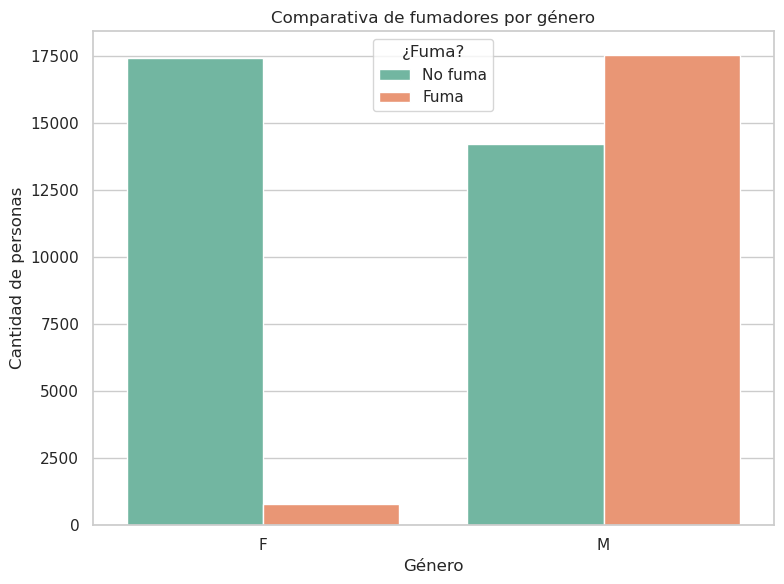

In [10]:
#Voy a hacer uan gráfica para poder representar y entender un poco mejor la composición de fumadores y no fumadores
conteo = df.groupby(['gender', 'smoking']).size().reset_index(name='count')
conteo['smoking'] = conteo['smoking'].map({0: 'No fuma', 1: 'Fuma'})
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(data=conteo, x='gender', y='count', hue='smoking', palette='Set2')
plt.title('Comparativa de fumadores por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de personas')
plt.legend(title='¿Fuma?')
plt.tight_layout()
plt.show()


In [11]:
from sklearn.preprocessing import OneHotEncoder

In [12]:
ohe = OneHotEncoder(sparse_output=False).fit(X_train[["tartar","oral", "gender"]])

In [13]:
encoded = ohe.transform((X_train[["tartar","oral", "gender"]]))

In [14]:
encoded_df = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded, index=X_train.index)

In [15]:
X_train = pd.concat([X_train, encoded_df], axis="columns")

In [16]:
X_train = X_train.drop(["tartar","oral", "gender"], axis=1)

In [17]:
#Replico el trabajo hecho con las dummies en el test
encoded_test = ohe.transform((X_test[["tartar","oral", "gender"]]))

In [18]:
encoded_df_test = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded_test, index=X_test.index)

In [19]:
X_test = pd.concat([X_test, encoded_df_test], axis="columns")

In [20]:
X_test = X_test.drop(["tartar","oral", "gender"], axis=1)

In [21]:
#Chequeo que ahora todas las variables sean compatibles on los árboles
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 8319 to 43737
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  35000 non-null  int64  
 1   height(cm)           35000 non-null  int64  
 2   weight(kg)           35000 non-null  int64  
 3   waist(cm)            35000 non-null  float64
 4   eyesight(left)       35000 non-null  float64
 5   eyesight(right)      35000 non-null  float64
 6   hearing(left)        35000 non-null  float64
 7   hearing(right)       35000 non-null  float64
 8   systolic             35000 non-null  float64
 9   relaxation           35000 non-null  float64
 10  fasting blood sugar  35000 non-null  float64
 11  Cholesterol          35000 non-null  float64
 12  triglyceride         35000 non-null  float64
 13  HDL                  35000 non-null  float64
 14  LDL                  35000 non-null  float64
 15  hemoglobin           35000 non-null  f

In [22]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 28092 to 9154
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  int64  
 1   height(cm)           15000 non-null  int64  
 2   weight(kg)           15000 non-null  int64  
 3   waist(cm)            15000 non-null  float64
 4   eyesight(left)       15000 non-null  float64
 5   eyesight(right)      15000 non-null  float64
 6   hearing(left)        15000 non-null  float64
 7   hearing(right)       15000 non-null  float64
 8   systolic             15000 non-null  float64
 9   relaxation           15000 non-null  float64
 10  fasting blood sugar  15000 non-null  float64
 11  Cholesterol          15000 non-null  float64
 12  triglyceride         15000 non-null  float64
 13  HDL                  15000 non-null  float64
 14  LDL                  15000 non-null  float64
 15  hemoglobin           15000 non-null  f

In [ ]:
#XGBoost es un método de gradient boosting basado en árboles que corrige iterativamente los errores previos ajustando pesos, tasa de aprendizaje y regularización para enfocarse en casos difíciles como los fumadores.

from xgboost import XGBClassifier 

In [25]:
xgClf = XGBClassifier()  #creo el modelo

In [26]:
xgClf.fit(X_train, y_train) #entreno el modelo

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [27]:
#Hago las prediciones
train_pred = xgClf.predict(X_train)
test_pred = xgClf.predict(X_test)

In [30]:
#Veo las analíticas para comparar los resultados
print("Train")
print(classification_report(y_train, train_pred))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred))

Train
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     22170
           1       0.82      0.84      0.83     12830

    accuracy                           0.87     35000
   macro avg       0.86      0.87      0.86     35000
weighted avg       0.87      0.87      0.87     35000

----------------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      9501
           1       0.68      0.71      0.69      5499

    accuracy                           0.77     15000
   macro avg       0.75      0.76      0.76     15000
weighted avg       0.77      0.77      0.77     15000



In [ ]:
#Con xgboost en la precisión vemos que en el train cuando una persona no fumo el modelo acierta un 91% de las veces, mientras que cuando fuma la persona el modelo acierta un 82%, si lo comparamos en el test los no fumadores acierta un 83% y los fumadores un 68%. Con respecto al recall, vemos que en el train acertó en el 89% del total de los que no fuman y un 84% en los que sí. mientras que en el test acertó en el 81% del total de los que no fuman y un 71% en los que sí. Si bien el accuracy da un %87 en el train y un 77% en el test, preocupa que el modelo falla mucho al acertar si la persona es fumadora.

In [32]:
#Los resultados fueron peores que con los parámetros calculados a ojo con elprimer modelo.
#Voy a cargar el DF con lo datos para entrega
df_entrega = pd.read_excel("../smoking_prediction_entrega.xlsx")

In [33]:
#Trabajo nuevamente el dataset para que pueda trabajar el modelo en las mismas condiciones que el dataset de entrenamiento. Genero las dummies y dropeo las columnas que no se unan. Seleccioné el modelo del Random Forest porque fue el modelo que me dió el mejor accuracy.
encoded_ohe_entrega = ohe.transform(df_entrega[["tartar", "oral", "gender"]])
encoded_df_entrega = pd.DataFrame(columns=ohe.get_feature_names_out(), data=encoded_ohe_entrega, index=df_entrega.index)
X_entrega = df_entrega.drop(["tartar", "oral", "gender", "ID"], axis=1).copy()
X_entrega_final = pd.concat([X_entrega, encoded_df_entrega], axis=1)
#Genero las predicciones de las personas nuevas
predicciones = xgClf.predict(X_entrega_final)
#Agrego al DF la columna smoking con las predicciones
df_entrega["smoking"] = predicciones

In [34]:
#Exporto al excel para la entrega
df_entrega.to_excel("dataset_output.xlsx", index=False)